# Fraud Detection Case — End‑to‑End Notebook

0. Environment Setup

In [1]:
import os, gc, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print(" All packages loaded successfully!")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

print({'lightgbm': HAS_LGBM, 'xgboost': HAS_XGB})

 All packages loaded successfully!
{'lightgbm': True, 'xgboost': True}


In [15]:
import pandas as pd

# Load file
df = pd.read_csv("c:\\Users\\Dell\\Desktop\\Fraud_detection\\Fraud.csv")

# Check actual shape
print("Shape:", df.shape)

# Check first few rows
print(df.head())

# Check last few rows
print(df.tail())

# Check if there are duplicate headers inside
print(df[df['step'] == 'step'].shape)



Shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
         step      type      amount     nameOrig  oldbalanceOrg  \
6362615   743  CA

**1. Config & Data Paths**

In [3]:
# ==== USER INPUTS ====
CSV_PATH = r"c:\Users\Dell\Desktop\Fraud_detection\Fraud.csv"   
TARGET = 'isFraud'               
ID_COLS = []       
DATETIME_COLS = []  
CATEGORICAL_HINT = ['type', 'nameOrig', 'nameDest']              
NUMERIC_HINT = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']                  

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

**2. Memory‑Efficient Data Loading**

In [4]:


# Preview total rows to infer dtypes and categories efficiently
preview = pd.read_csv(CSV_PATH,nrows=1048576)   
print('Preview shape:', preview.shape)

# Show unique transaction types and their counts
print("\nTransaction type distribution:")
print(preview['type'].value_counts())



Preview shape: (1048576, 11)

Transaction type distribution:
type
CASH_OUT    373641
PAYMENT     353874
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64


In [18]:
print(df.shape)


(6362620, 11)


In [5]:
# Helper: infer dtypes (downcast numerics, detect low-cardinality categoricals)
def infer_dtypes(df, categorical_hint=None, numeric_hint=None, cat_threshold=100):
    dtypes = {}
    cat_cols = set(categorical_hint or [])
    num_cols = set(numeric_hint or [])
    for col in df.columns:
        if col in cat_cols:
            dtypes[col] = 'category'
        elif col in num_cols:
            dtypes[col] = 'float64'
        else:
            if pd.api.types.is_numeric_dtype(df[col]):
                dtypes[col] = 'float64'
            elif pd.api.types.is_datetime64_any_dtype(df[col]):
                dtypes[col] = 'datetime64[ns]'
            else:
                if df[col].dtype == 'object' and df[col].nunique(dropna=True) <= cat_threshold:
                    dtypes[col] = 'category'
                else:
                    dtypes[col] = 'object'
    return dtypes

inferred = infer_dtypes(preview, CATEGORICAL_HINT, NUMERIC_HINT)
inferred

{'step': 'float64',
 'type': 'category',
 'amount': 'float64',
 'nameOrig': 'category',
 'oldbalanceOrg': 'float64',
 'newbalanceOrig': 'float64',
 'nameDest': 'category',
 'oldbalanceDest': 'float64',
 'newbalanceDest': 'float64',
 'isFraud': 'float64',
 'isFlaggedFraud': 'float64'}

In [6]:
# Full load with dtype hints (except datetime which we parse)
parse_dates = [c for c in DATETIME_COLS if c in preview.columns]
dtype_map = {k:v for k,v in inferred.items() if v not in ['datetime64[ns]']}
df = pd.read_csv(CSV_PATH, dtype=dtype_map, parse_dates=parse_dates, low_memory=True)
print('Full shape:', df.shape)
df.head(5)

Full shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1.0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1.0,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1.0,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1.0,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1.0,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


 3. Basic Data QA

In [7]:
display(pd.DataFrame({'dtype': df.dtypes.astype(str), 'n_unique': df.nunique(), 'missing_%': df.isna().mean().round(4)}))

,dtype,n_unique,missing_%
step,float64,743,0.0
type,category,5,0.0
amount,float64,5316900,0.0
nameOrig,category,6353307,0.0
oldbalanceOrg,float64,1845844,0.0
newbalanceOrig,float64,2682586,0.0
nameDest,category,2722362,0.0
oldbalanceDest,float64,3614697,0.0
newbalanceDest,float64,3555499,0.0
isFraud,float64,2,0.0


**4. Split: Calibration (Train) & Validation**

In [8]:
# Define the list of ID columns and the target column
ID_COLS = []  
TARGET = "isFraud"                        
# Drop IDs from features; keep target
X = df.drop(columns=[c for c in ID_COLS if c in df.columns] + [TARGET])
y = df[TARGET]
if y.dtype == "object" or str(y.dtype) == "category":
    le = LabelEncoder()
    y = le.fit_transform(y)

# Separate column types
cat_cols = [c for c in X.columns if str(X[c].dtype) == 'category' or X[c].dtype == 'object']
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(X_train.shape, X_valid.shape, y_train.mean().round(6), y_valid.mean().round(6))

(5090096, 10) (1272524, 10) 0.001291 0.001291


**5. Data Cleaning: Missing Values, Outliers, Multicollinearity**

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Imputers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore',sparse_output=True,max_categories=50))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Helper: VIF on numeric columns (after median imputation)
num_sample = X_train[num_cols].copy()
for c in num_cols:
    num_sample[c] = num_sample[c].fillna(num_sample[c].median())

if len(num_cols) >= 2:
    X_vif = add_constant(num_sample)
    vif = pd.DataFrame({
        'feature': ['const'] + num_cols,
        'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    })
    display(vif.sort_values('VIF', ascending=False).head(15))
else:
    print("Not enough numeric columns for VIF analysis.")


,feature,VIF
4,newbalanceOrig,430.990121
3,oldbalanceOrg,429.952820
6,newbalanceDest,75.382696
5,oldbalanceDest,65.505786
0,const,4.137217
2,amount,3.704947
1,step,1.002425
7,isFlaggedFraud,1.000734


In [11]:
# Simple outlier treatment for numeric columns using IQR capping (winsorization)
def iqr_cap(series, k=1.5):
    q1, q3 = np.nanpercentile(series, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - k*iqr, q3 + k*iqr
    return np.clip(series, lower, upper)

X_train_capped = X_train.copy()
for c in num_cols:
    X_train_capped[c] = iqr_cap(X_train_capped[c].astype(float))

X_valid_capped = X_valid.copy()
for c in num_cols:
    X_valid_capped[c] = iqr_cap(X_valid_capped[c].astype(float))

**6. Baseline Model — Logistic Regression**

LogReg (baseline) — ROC AUC: 0.9122 | PR AUC: 0.0118
              precision    recall  f1-score   support

         0.0     1.0000    0.5665    0.7233   1270881
         1.0     0.0030    0.9994    0.0059      1643

    accuracy                         0.5671   1272524
   macro avg     0.5015    0.7830    0.3646   1272524
weighted avg     0.9987    0.5671    0.7224   1272524



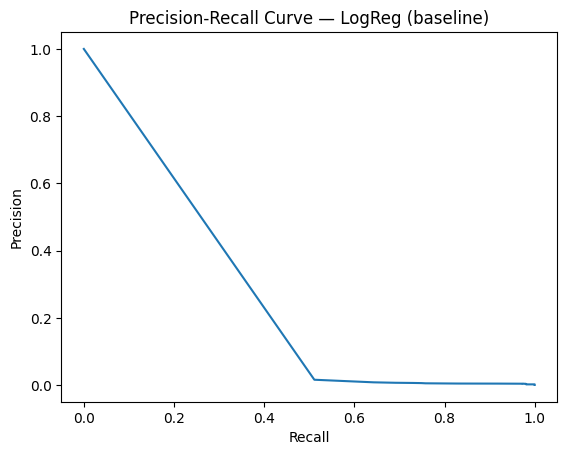

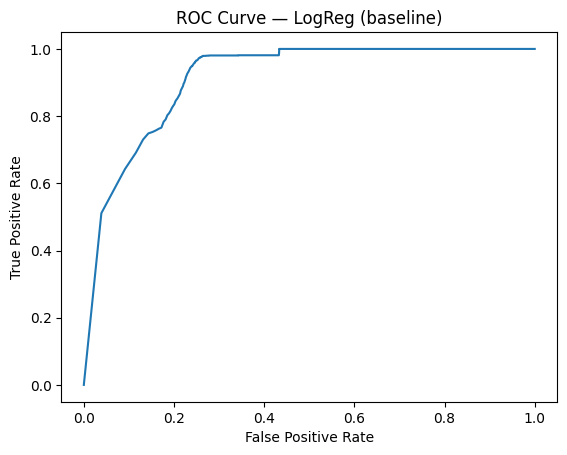

In [12]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, classification_report
)
import matplotlib.pyplot as plt

baseline = ImbPipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=None))
])

baseline.fit(X_train, y_train)

def eval_model(model, Xv, yv, name='model'):
    proba = model.predict_proba(Xv)[:,1]
    roc = roc_auc_score(yv, proba)
    pr = average_precision_score(yv, proba)

    fpr, tpr, roc_th = roc_curve(yv, proba)
    prec, rec, pr_th = precision_recall_curve(yv, proba)

    print(f"{name} — ROC AUC: {roc:.4f} | PR AUC: {pr:.4f}")
    y_pred = (proba >= 0.5).astype(int)
    print(classification_report(yv, y_pred, digits=4))

    # Plot PR curve
    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve — {name}')
    plt.show()

    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}')
    plt.show()

    return proba

proba_baseline = eval_model(baseline, X_valid_capped, y_valid, name='LogReg (baseline)')


**7. Advanced Model — Gradient Boosting (LightGBM / XGBoost / RandomForest Fallback)**

[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.624410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1654
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM — ROC AUC: 0.9841 | PR AUC: 0.5529
              precision    recall  f1-score   support

         0.0     0.9996    0.9985    0.9991   1270881
         1.0     0.3783    0.6987    0.4908      1643

    accuracy                         0.9981   1272524
   macro avg     0.6889    0.8486    0.7449   1272524
weighted avg     0.9988    0.9981    0.9984   1272524



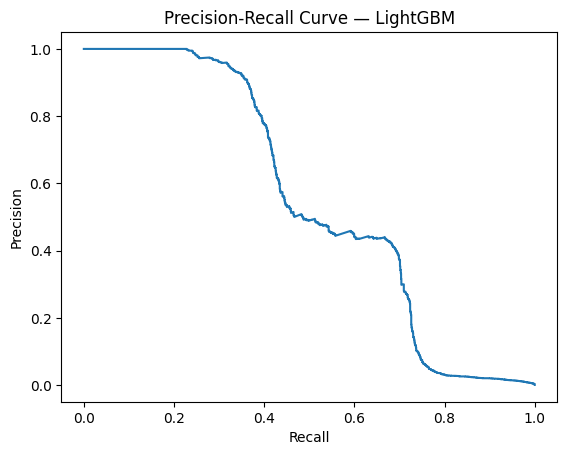

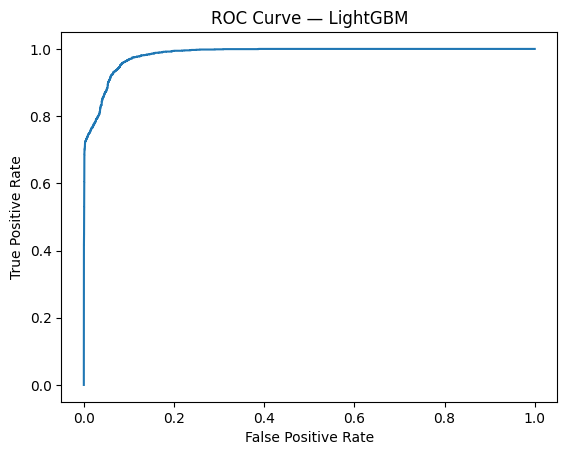

XGBoost — ROC AUC: 0.9976 | PR AUC: 0.7468
              precision    recall  f1-score   support

         0.0     0.9994    1.0000    0.9997   1270881
         1.0     0.9733    0.5332    0.6890      1643

    accuracy                         0.9994   1272524
   macro avg     0.9864    0.7666    0.8443   1272524
weighted avg     0.9994    0.9994    0.9993   1272524



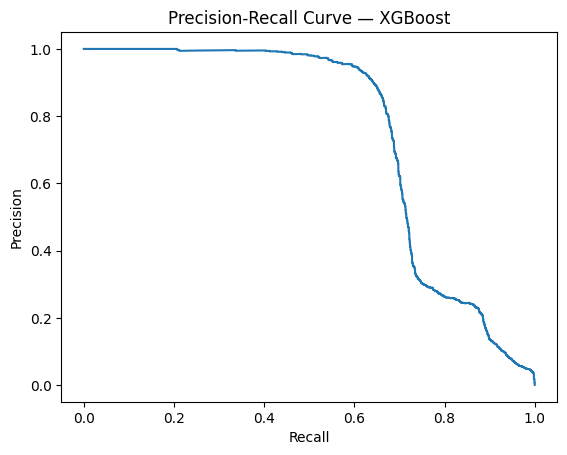

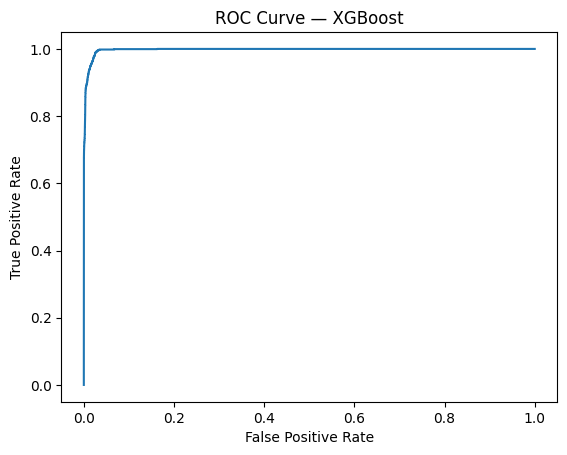

RandomForest — ROC AUC: 0.9076 | PR AUC: 0.7170
              precision    recall  f1-score   support

         0.0     0.9990    1.0000    0.9995   1270881
         1.0     0.9929    0.2568    0.4081      1643

    accuracy                         0.9990   1272524
   macro avg     0.9960    0.6284    0.7038   1272524
weighted avg     0.9990    0.9990    0.9988   1272524



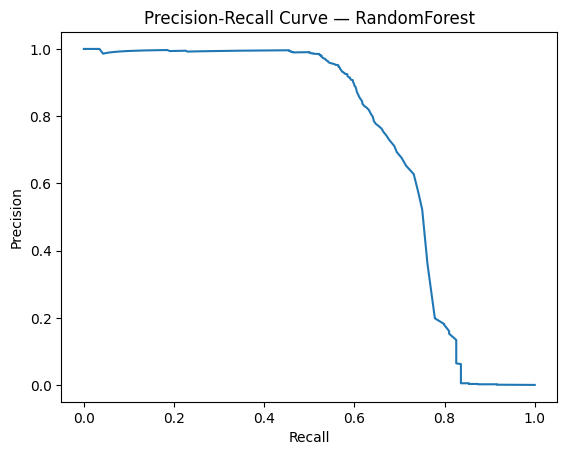

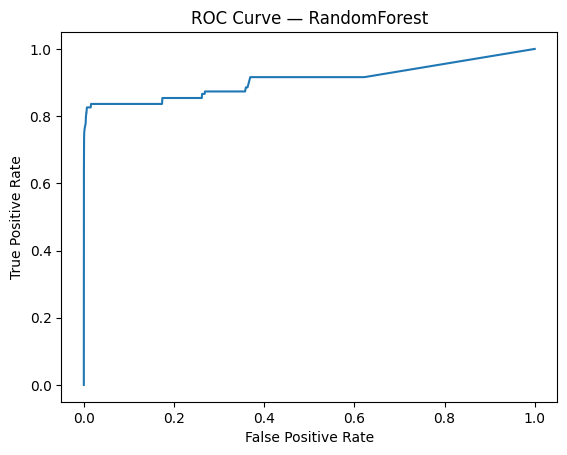

Best model by PR AUC: XGBoost 0.7468109270173691


In [14]:
import lightgbm as lgb
import xgboost as xgb  
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, roc_curve, classification_report

RANDOM_STATE=42

models = []

HAS_LGBM = True   
HAS_XGB = True    

if HAS_LGBM:
    lgbm_clf = lgb.LGBMClassifier(random_state=RANDOM_STATE, n_estimators=500, subsample=0.8, colsample_bytree=0.8,
                                  learning_rate=0.05, class_weight='balanced')
    models.append(('LightGBM', lgbm_clf))
if HAS_XGB:
    xgb_clf = xgb.XGBClassifier(random_state=RANDOM_STATE, n_estimators=500, subsample=0.8, colsample_bytree=0.8,
                                learning_rate=0.05, eval_metric='logloss', scale_pos_weight=1.0)
    models.append(('XGBoost', xgb_clf))

rf_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced_subsample', n_jobs=-1)
models.append(('RandomForest', rf_clf))




results = []
for name, clf in models:
    pipe = ImbPipeline(steps=[('preprocess', preprocess), ('clf', clf)])
    pipe.fit(X_train, y_train)
    proba = eval_model(pipe, X_valid_capped, y_valid, name=name)
    results.append((name, pipe, proba))

# Pick best by PR AUC
best = None
best_score = -1
for name, pipe, proba in results:
    pr = average_precision_score(y_valid, proba)
    if pr > best_score:
        best_score = pr
        best = (name, pipe, proba)

print('Best model by PR AUC:', best[0], best_score)

**8. Threshold Tuning (F1 & Cost‑Aware)**


In [15]:
name, best_pipe, proba_best = best
y = y_valid.values

def tune_threshold(y_true, y_proba, cost_fp=1, cost_fn=10):
    # Grid search thresholds
    ths = np.linspace(0.01, 0.99, 99)
    best_f1, best_f1_th = -1, 0.5
    best_cost, best_cost_th = 1e18, 0.5
    for th in ths:
        y_hat = (y_proba >= th).astype(int)
        f1 = f1_score(y_true, y_hat)
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
        cost = cost_fp*fp + cost_fn*fn
        if f1 > best_f1:
            best_f1, best_f1_th = f1, th
        if cost < best_cost:
            best_cost, best_cost_th = cost, th
    return {'best_f1': (best_f1, best_f1_th), 'best_cost': (best_cost, best_cost_th)}

tuned = tune_threshold(y, proba_best, cost_fp=1, cost_fn=10)
tuned


{'best_f1': (0.7506155469574394, np.float64(0.2)),
 'best_cost': (np.int64(5577), np.float64(0.060000000000000005))}

In [ ]:
best_f1, f1_th = tuned['best_f1']
best_cost, cost_th = tuned['best_cost']
print(f"Best F1: {best_f1:.4f} at threshold {f1_th:.2f}")
print(f"Best cost: {best_cost:.0f} at threshold {cost_th:.2f} (cost_fn=10x cost_fp)")

Best F1: 0.7506 at threshold 0.20
Best cost: 5577 at threshold 0.06 (cost_fn=10x cost_fp)


**9. Explainability — Top Predictors**

In [ ]:
r = permutation_importance(best[1], X_valid_capped, y_valid, n_repeats=5, random_state=RANDOM_STATE, scoring='average_precision')
importances = pd.DataFrame({'feature': best[1].named_steps['preprocess'].get_feature_names_out(), 'importance': r.importances_mean})
top_imp = importances.sort_values('importance', ascending=False).head(25).reset_index(drop=True)
top_imp

In [ ]:
plt.figure()
plt.barh(top_imp['feature'][::-1], top_imp['importance'][::-1])
plt.xlabel('Mean Importance (Permutation)')
plt.title('Top 25 Predictive Features')
plt.tight_layout()
plt.show()

**Optional: SHAP values (if using tree models)**

In [ ]:
try:
    import shap
    explainer = None
    model = best[1].named_steps['clf']
    # SHAP on tree models only
    if HAS_LGBM and hasattr(model, 'predict_proba') and 'LGBM' in best[0]:
        explainer = shap.TreeExplainer(model)
    elif HAS_XGB and hasattr(model, 'predict_proba') and 'XGBoost' in best[0]:
        explainer = shap.TreeExplainer(model)
    if explainer is not None:
        # Get transformed validation set for SHAP
        Xv = best[1].named_steps['preprocess'].transform(X_valid_capped)
        shap_values = explainer.shap_values(Xv)
        shap.summary_plot(shap_values, Xv, show=True)
    else:
        print('SHAP is configured for tree models only in this scaffold.')
except Exception as e:
    print('SHAP skipped:', e)

**10. Insights → Actionable Plan**

Use the top drivers, partial dependence/SHAP, and error analysis to propose:

- **Rule enhancements**: e.g., hard blocks for impossible geographies, velocity limits.

- **Step-up auth**: MFA, OTP, device fingerprint checks for risky segments.

- **Limits & holds**: lower limits or manual review for high‑risk patterns.

- **Data collection**: capture missing signals that improved model performance.

- **Monitoring**: drift, precision@topK, alert volumes, false positive cost.
